Import Libraries such as Pandas, Datasets, Matplotlib.pyplot and Seaborn.

In [1]:
import ast # For string conversion into list object
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
# make datetime string into datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# in column job_skills, make list from string into panda series (list) object using ast.literal_eval
df["job_skills"] = df["job_skills"].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else None)

# Highest Skills in Data Job Postings

Filter the dataframe to show job postings from the United Kingdom whilst ensuring to create a copy of it also for data integrity.

In [2]:
# Filter df for jobs in United Kingdom
df_UK = df[(df["job_country"] == "United Kingdom")].copy()

As I have made the values in column job_skills from string into list object, they are now 'explodable' and can be exploded into multiple rows. Below they are exploded and aggregated by job title to show the count of each skill required for that job title.

In [3]:
# Explode job_skills list (unpivot this column)
df_skills = df_UK.explode("job_skills")

# Group by to see how many jobs per skill grouped by job title
df_skills_count = df_skills.groupby(["job_skills", "job_title_short"]).size()

In [ ]:
df_skills_count

job_skills  job_title_short          
airflow     Business Analyst                1
            Cloud Engineer                  6
            Data Analyst                   41
            Data Engineer                1062
            Data Scientist                141
                                         ... 
zoom        Machine Learning Engineer       3
            Senior Data Analyst             2
            Senior Data Engineer            6
            Senior Data Scientist           4
            Software Engineer               1
Length: 1419, dtype: int64

Convert this series (returned by groupby) into a dataframe by resetting index and naming the count column to skill_count. This dataframe is then sorted by skill count in descending order.

In [ ]:
df_skills_count = df_skills_count.reset_index(name="skill_count")

df_skills_count.sort_values(by="skill_count", ascending=False, inplace=True)

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

In [11]:
df_skills_count

,level_0,index,job_skills,job_title_short,skill_count
0,0,1163,sql,Data Engineer,7050
1,1,915,python,Data Engineer,6462
2,2,916,python,Data Scientist,6329
3,3,88,azure,Data Engineer,4865
4,4,1162,sql,Data Analyst,4467
...,...,...,...,...,...
1414,1414,1368,vue.js,Software Engineer,1
1415,1415,1367,vue.js,Senior Data Engineer,1
1416,1416,514,javascript,Machine Learning Engineer,1
1417,1417,551,julia,Software Engineer,1


Now, I want to plot the skills demanded for a target subset of job titles related to the data profession. They are: Data Analyst, Data Engineer and Data Scientist. I then want to plot them all on three subplots for comparison purposes.

So, I put the three job titles in a list and assign the list to variable job_list

In [ ]:
job_list = ["Data Analyst", "Data Engineer", "Data Scientist"]

I then define a subplot canvas which is one plot on the horizontal axis but the vertical axis is the length of the variable job_list. This makes it a maintainable solution by ensuring that if I wanted to increase or decrease the number of job titles and the resultant subplots, I only need to change the variable job_list. I do not need to change the subplot code below.

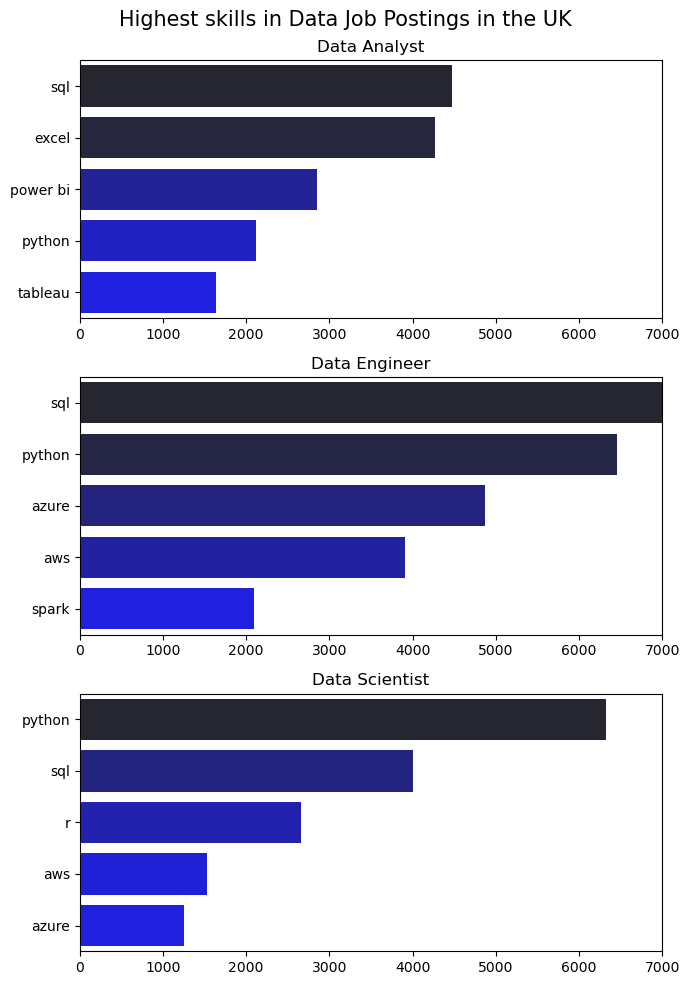

In [17]:
# Set up grid layout and figure size
fig, ax = plt.subplots(len(job_list), 1, figsize=(7, 10))

# Use for loop to interate over job_list and bring top 5 skills for each job title
for i, job_name in enumerate(job_list):
    df_plot = df_skills_count[df_skills_count["job_title_short"] == job_name].head(5)
    sns.barplot(
        data=df_plot,
        y="job_skills", # Swap x and y values to make it horizontal bar plot
        x="skill_count",
        ax=ax[i],
        legend=False,

        hue="skill_count",
        palette="dark:b_r"
    )
    ax[i].set_title(job_name)
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")
    ax[i].set_xlim(0, 7000) # Ensure uniformity in x axis values for ease of comparison

fig.suptitle("Highest skills in Data Job Postings in the UK", fontsize=15)
fig.tight_layout() # Prevent overlap between plots
plt.show();

# Likelihood of Skills in Data Job Postings

In [6]:
# Return total number of each job and make it into dataframe
df_job_counts = df_UK["job_title_short"].value_counts().reset_index(name="job_counts")

df_job_counts

,job_title_short,job_counts
0,Data Engineer,11807
1,Data Analyst,10482
2,Data Scientist,9148
3,Senior Data Engineer,3337
4,Senior Data Scientist,2367
5,Senior Data Analyst,1356
6,Business Analyst,827
7,Software Engineer,541
8,Machine Learning Engineer,317
9,Cloud Engineer,193


In [7]:
df_skills_percentage = pd.merge(df_skills_count, df_job_counts, how="left", on="job_title_short")

df_skills_percentage["Percentage"] = (df_skills_percentage["skill_count"] / df_skills_percentage["job_counts"]) * 100

In [8]:
df_skills_percentage

,job_skills,job_title_short,skill_count,job_counts,Percentage
0,sql,Data Engineer,7050,11807,59.710341
1,python,Data Engineer,6462,11807,54.730245
2,python,Data Scientist,6329,9148,69.184521
3,azure,Data Engineer,4865,11807,41.204370
4,sql,Data Analyst,4467,10482,42.615913
...,...,...,...,...,...
1414,vue.js,Software Engineer,1,541,0.184843
1415,vue.js,Senior Data Engineer,1,3337,0.029967
1416,javascript,Machine Learning Engineer,1,317,0.315457
1417,julia,Software Engineer,1,541,0.184843


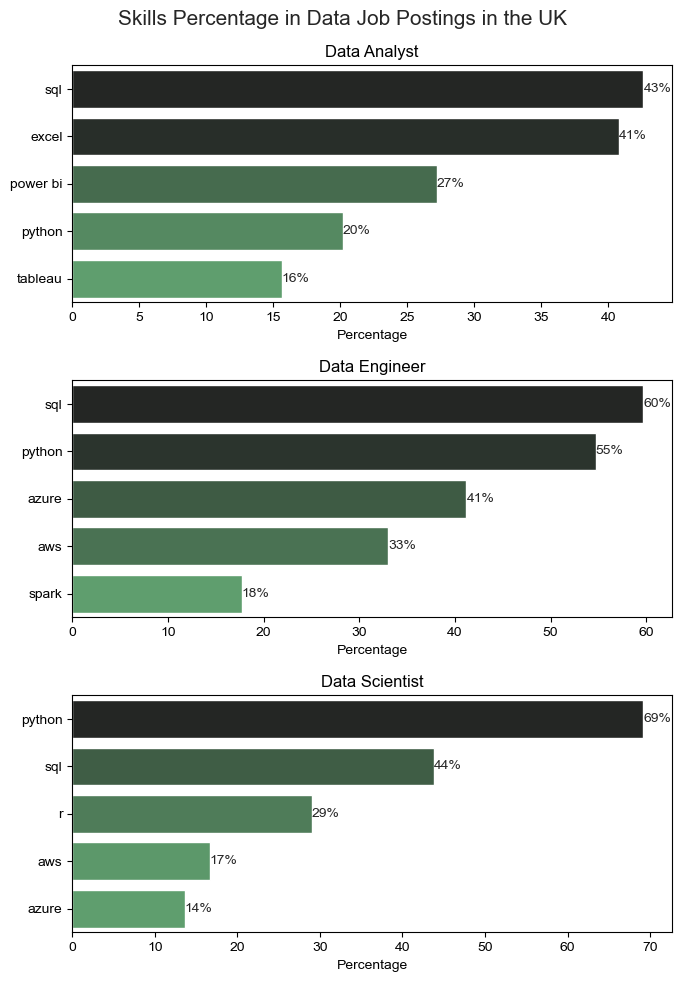

In [ ]:
# Plot the top 3 job titles in subplots as percentages
fig, ax = plt.subplots(len(job_list), 1, figsize=(7, 10))
sns.set_theme(style="ticks")

# Use for loop to interate over job_list and bring top 5 skills with highest counts 
for i, job_name in enumerate(job_list):
    df_plot = df_skills_percentage[df_skills_percentage["job_title_short"] == job_name].head(5)
    # Plot using Seaborn
    sns.barplot(
        data=df_plot,
        y="job_skills", # Swap x and y values to make it horizontal bar plot
        x="Percentage",
        ax=ax[i],
        legend=False,

        hue="Percentage",
        palette="dark:g_r"
    )
    ax[i].set_title(job_name)
    ax[i].set_ylabel("")

    # Add the percentage datalabels for each bar
    # NOTE: container is the group of bars inside a plot, so we access the data value in each container
    for container in ax[i].containers:
        ax[i].bar_label(container, fmt="%.0f%%", fontsize=10)
    

fig.suptitle("Skills Percentage in Data Job Postings in the UK", fontsize=15)
fig.tight_layout(); # Prevent overlap between plots

plt.show()
